# AKASH Notebook 1 — Bangla Space Q&A Corpus (Gemma-4-12B Unified Edition)

**Project:** AKASH — Bengali Space Tutor for Kids (Build with Gemma)
**Author:** AKASH Team (Member 1 — The Brain)
**Runtime:** Kaggle GPU (T4 / L4 recommended), ~1-2 hours
**Output:** `akash_bangla_space_qa.jsonl` (~1,500-3,000 rows)

---

## What changed in this version

This version loads **`google/gemma-4-12B-it`** (Gemma 4 12B Unified)
directly from Hugging Face using the official `transformers` API
(`AutoProcessor` + `AutoModelForMultimodalLM`), instead of the larger
31B model used in the previous version.

Why we switched to Gemma 4 12B Unified:
- The 12B Unified model uses an **encoder-free architecture** — raw image
  patches and audio waveforms are projected directly into the LLM's embedding
  space through lightweight linear layers, reducing multimodal latency.
- At ~12B parameters, the model fits comfortably on a **single T4 (16 GB)**
  or L4 in bf16 without 4-bit quantization, making deployment simpler and faster.
- It supports **Text, Image, and Audio** modalities (unlike the 31B which
  only supports Text and Image — no audio encoder).
- The 12B model has a **256K token context window** (same as 31B), supports
  native system prompts, configurable thinking mode, and function calling.
- It achieves strong benchmark scores: MMLU Pro 77.2%, LiveCodeBench v6 72%,
  MMMU Pro 69.1% — excellent for a 12B-parameter model.
- `transformers` AutoProcessor / AutoModelForMultimodalLM is the canonical
  Hugging Face pattern shown on the model card, and works the same on Kaggle,
  Colab, and local boxes.

## What you need before running

1. A Hugging Face account.
2. Accept the Gemma license on the model page:
   https://huggingface.co/google/gemma-4-12B-it
3. Create a HF access token (read scope is enough):
   https://huggingface.co/settings/tokens
4. Add the token to Kaggle as a secret named **`HF_TOKEN`**:
   `Add-ons → Secrets → Add a new secret`.

## What this notebook does (Gemma-only pipeline)

1. **Synthetic Q&A generation** — Gemma generates kid-friendly Bangla space Q&A pairs via few-shot prompting.
2. **Bangla translation** — Gemma translates NASA Space Place facts from English to Bangla.
3. **Self-evaluation & filtering** — Gemma scores its own outputs for kid-friendliness, factual accuracy, and Bangla fluency.

> ⚠️ **Model name note**: This notebook uses `google/gemma-4-12B-it`
> (Gemma 4 12B Unified, instruction-tuned). If you want a smaller model,
> set `MODEL_NAME` below to `google/gemma-4-E4B-it` or `google/gemma-4-E2B-it`.


## 1. Environment Setup

We only need **`transformers`**, **`accelerate`**, and **`bitsandbytes`** (for optional 4-bit loading).
No Unsloth, no `unsloth_zoo`, no Kaggle model mount.

> ⚠️ **Important**: After running the install cell, the imports cell MUST run in a separate cell.
> If you put them in the same cell, Python's cached module state will cause `ImportError`
> on the first run.

> 💡 **Note for 12B Unified**: The 12B model (~24 GB in bf16) fits on a single L4
> or T4 x2 without 4-bit quantization. On a single T4 (16 GB), you may need
> `USE_4BIT = True` or `device_map="auto"` sharding. 4-bit brings it down to ~7 GB.


In [1]:
# === PIP INSTALL ONLY — do NOT import in this cell ===
# Splitting install and import is CRITICAL on Kaggle. If you import in the
# same cell as the pip install, Python uses cached module state and crashes
# with ImportError on the first run. We do imports in the next cell.

# Core: up-to-date transformers ships AutoProcessor + AutoModelForMultimodalLM
# (the multimodal Gemma 4 loader).
!pip install -q -U "transformers>=4.45.0"

# accelerate: required for device_map="auto" on multi-GPU / sharded loading
!pip install -q -U "accelerate>=0.30.0"

# bitsandbytes: enables optional 4-bit NF4 quantization. The 12B Unified model
# fits on a single L4 or T4 x2 in bf16 (~24 GB), so 4-bit is OPTIONAL.
# On a single T4 (16 GB), set USE_4BIT=True to reduce memory to ~7 GB.
!pip install -q -U "bitsandbytes>=0.43.0"

# huggingface_hub: for login(token=...) and snapshot downloads
!pip install -q -U "huggingface_hub>=0.24.0"

# kaggle CLI for the optional dataset publish step at the end
!pip install -q "kaggle>=1.6.0"

print()
print("=" * 60)
print("✓ Install complete. Run the NEXT cell to import everything.")
print("=" * 60)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 91.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 771.9/771.9 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.2/119.2 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 88.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.

✓ Install complete. Run the NEXT cell to import everything.


In [2]:
# === IMPORTS — run this AFTER the install cell above ===
# Standard library
import os, json, time, random, hashlib, re, sys, glob, gc, shutil, subprocess
from pathlib import Path
from datetime import datetime
from collections import Counter

# Third-party (pre-installed on Kaggle + the ones we just installed)
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# HuggingFace stack
import transformers
from transformers import (
    AutoProcessor,
    AutoModelForMultimodalLM,
    BitsAndBytesConfig,
)
from huggingface_hub import login, whoami

print(f"✓ transformers: {transformers.__version__}")
print(f"✓ torch: {torch.__version__}")

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print()
print(f"⏱  Notebook started at: {datetime.now().isoformat()}")
print(f"🐍 Python: {sys.version.split()[0]}")
print(f"🖥  CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"    GPU: {torch.cuda.get_device_name(0)}")
    print(f"    VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    print(f"    CUDA version: {torch.version.cuda}")
    print(f"    bf16 supported: {torch.cuda.is_bf16_supported()}")


✓ transformers: 5.14.1
✓ torch: 2.10.0+cu128

⏱  Notebook started at: 2026-07-23T07:37:11.833651
🐍 Python: 3.12.13
🖥  CUDA available: True
    GPU: Tesla T4
    VRAM: 15.6 GB
    CUDA version: 12.8
    bf16 supported: True


## 2. Hugging Face Authentication

Loading `google/gemma-4-12B-it` from Hugging Face requires:

1. You have **accepted the Gemma license** on the model page
   (https://huggingface.co/google/gemma-4-12B-it).
2. Kaggle has a secret called **`HF_TOKEN`** with a read-scope token from
   https://huggingface.co/settings/tokens.

The cell below reads that secret and logs you in. If you are running this
notebook outside Kaggle, set the `HF_TOKEN` environment variable manually
before launching Jupyter.


In [3]:
# === Read HF_TOKEN from Kaggle Secrets and log in ===
HF_TOKEN = None

# Kaggle path
try:
    from kaggle_secrets import UserSecretsClient
    HF_TOKEN = UserSecretsClient().get_secret("HF_TOKEN")
    print("✓ HF_TOKEN loaded from Kaggle Secrets")
except Exception:
    # Fallback to env var (Colab / local)
    HF_TOKEN = os.environ.get("HF_TOKEN")
    if HF_TOKEN:
        print("✓ HF_TOKEN loaded from environment variable")
    else:
        print("⚠ No HF_TOKEN found in Kaggle Secrets or environment.")
        print("  Set it as a Kaggle Secret named 'HF_TOKEN', or export HF_TOKEN=...")

if not HF_TOKEN:
    raise RuntimeError(
        "HF_TOKEN is required to download google/gemma-4-12B-it from Hugging Face.\n"
        "1. Accept the license at https://huggingface.co/google/gemma-4-12B-it\n"
        "2. Create a token at https://huggingface.co/settings/tokens\n"
        "3. Add it as a Kaggle Secret named HF_TOKEN (or export HF_TOKEN env var)."
    )

os.environ["HF_TOKEN"] = HF_TOKEN
login(token=HF_TOKEN)

try:
    me = whoami(token=HF_TOKEN)
    print(f"✓ Logged in as: {me.get('name', '?')}")
except Exception as e:
    print(f"  (whoami check skipped: {e})")


✓ HF_TOKEN loaded from Kaggle Secrets


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


✓ Logged in as: Sakhawathossen


## 3. Load `google/gemma-4-12B-it` with `AutoProcessor` + `AutoModelForMultimodalLM`

We use the canonical Hugging Face loader shown on the Gemma 4 model card:

```python
processor = AutoProcessor.from_pretrained(MODEL_ID)
model     = AutoModelForMultimodalLM.from_pretrained(MODEL_ID, dtype="auto", device_map="auto")
```

Important notes for **Gemma 4 12B Unified**:

- **Encoder-free architecture**: Unlike other Gemma 4 models that use dedicated
  encoders for multimodal data, the 12B Unified model projects raw image patches
  and audio waveforms directly into the LLM's embedding space through lightweight
  linear layers. All modalities flow through a single decoder-only transformer.
- **`USE_4BIT = False`** — The 12B model in bf16 is ~24 GB. It fits on a single
  L4 (24 GB) or T4 x2 (32 GB combined). On a single T4 (16 GB), set `USE_4BIT = True`
  to reduce memory to ~7 GB, or rely on `device_map="auto"` CPU offloading.
- **`dtype="auto"`** — We follow the official model card example, using `dtype="auto"`
  instead of manually specifying `torch_dtype`.
- **256K context window** — The 12B model supports up to 256K tokens (same as 31B).
  We keep `MAX_SEQ_LENGTH = 2048` for synthesis prompts.
- **Audio support** — The 12B Unified model natively supports Audio input (ASR
  and AST), unlike the 31B which has no audio encoder.
- **Thinking mode** — Gemma 4 introduces configurable thinking via `<|think|>`
  token in the system prompt. We keep thinking disabled (`enable_thinking=False`)
  for deterministic Q&A generation.
- **Hybrid attention** — The model uses interleaved local sliding window (1024 tokens)
  and full global attention, with unified KV cache and Proportional RoPE (p-RoPE).


In [4]:
# === Load google/gemma-4-12B-it via AutoProcessor + AutoModelForMultimodalLM ===
# Per the official Gemma 4 model card, we use dtype="auto" and device_map="auto"
# as shown in the canonical example code.

MODEL_NAME = "google/gemma-4-12B-it"
MAX_SEQ_LENGTH = 2048
USE_4BIT = False  # 12B fits on L4/T4x2 in bf16; set True on single T4 (16GB)

# Pick the best compute dtype for this GPU
compute_dtype = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16

# Build optional 4-bit quantization config
quantization_config = None
if USE_4BIT:
    quantization_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=compute_dtype,
        bnb_4bit_use_double_quant=True,
    )

model_size_estimate = "~24 GB (bf16)" if not USE_4BIT else "~7 GB (4-bit NF4)"
print(f"⏳ Loading model: {MODEL_NAME}")
print(f"   4-bit quantization: {USE_4BIT}")
print(f"   Compute dtype: {compute_dtype}")
print(f"   Expected VRAM: {model_size_estimate}")
print(f"   (Downloads ~12 GB on first run. Subsequent Kaggle runs use cache.)")
print(f"   Architecture: Gemma 4 12B Unified (encoder-free, no separate vision/audio encoders)")

processor = AutoProcessor.from_pretrained(MODEL_NAME, token=HF_TOKEN)

# Per Gemma 4 model card: use dtype="auto" (replaces deprecated torch_dtype)
model = AutoModelForMultimodalLM.from_pretrained(
    MODEL_NAME,
    token=HF_TOKEN,
    device_map="auto",
    quantization_config=quantization_config,
    dtype="auto",   # official model card parameter
)
model.eval()

# --- Safe config reader ---
# Gemma 4 configs (Gemma4Config) are COMPOSITE: text params live under
# model.config.text_config, not model.config directly.
def cfg_get(config, attr, default="N/A"):
    if hasattr(config, attr):
        return getattr(config, attr)
    if hasattr(config, "text_config") and hasattr(config.text_config, attr):
        return getattr(config.text_config, attr)
    return default

print(f"\n✓ Model loaded: {MODEL_NAME}")
print(f"  Model type: Gemma 4 12B Unified (encoder-free)")
print(f"  Total parameters: 11.95B (12B Unified)")
print(f"  Hidden size: {cfg_get(model.config, 'hidden_size')}")
print(f"  Num layers: {cfg_get(model.config, 'num_hidden_layers')}")
print(f"  Vocab size: {cfg_get(model.config, 'vocab_size')}")
print(f"  Context window: 256K tokens")
print(f"  Sliding window: 1024 tokens")
print(f"  Supported modalities: Text, Image, Audio")
if torch.cuda.is_available():
    print(f"  GPU memory allocated: {torch.cuda.memory_allocated() / 1e9:.2f} GB")
    print(f"  GPU memory reserved:  {torch.cuda.memory_reserved() / 1e9:.2f} GB")


⏳ Loading model: google/gemma-4-12B-it
   4-bit quantization: False
   Compute dtype: torch.bfloat16
   Expected VRAM: ~24 GB (bf16)
   (Downloads ~12 GB on first run. Subsequent Kaggle runs use cache.)
   Architecture: Gemma 4 12B Unified (encoder-free, no separate vision/audio encoders)


processor_config.json:   0%|          | 0.00/1.38k [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/18.7k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.42k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/3.09k [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 23.9GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/677 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/260 [00:00<?, ?B/s]


✓ Model loaded: google/gemma-4-12B-it
  Model type: Gemma 4 12B Unified (encoder-free)
  Total parameters: 11.95B (12B Unified)
  Hidden size: 3840
  Num layers: 48
  Vocab size: 262144
  Context window: 256K tokens
  Sliding window: 1024 tokens
  Supported modalities: Text, Image, Audio
  GPU memory allocated: 11.98 GB
  GPU memory reserved:  12.00 GB


## 4. Define the 50 Space Topics + Hand-Written Seed Q&A

These are the **only non-Gemma inputs** in the entire pipeline. For 5 topics we
hand-wrote 3 high-quality seed Q&A pairs in Bangla — 15 seeds total. For the
remaining 45 topics we use simple templated seeds. Gemma's few-shot prompt
expands them into rich Q&A pairs.


In [5]:
# 50 space topics — same list as the AKASH website
TOPICS = [
    ("sun",         "সূর্য",        "Sun",         "solar_system"),
    ("moon",        "চাঁদ",         "Moon",        "solar_system"),
    ("earth",       "পৃথিবী",      "Earth",       "solar_system"),
    ("mars",        "মঙ্গল",        "Mars",        "solar_system"),
    ("venus",       "শুক্র",        "Venus",       "solar_system"),
    ("mercury",     "বুধ",          "Mercury",     "solar_system"),
    ("jupiter",     "বৃহস্পতি",     "Jupiter",     "solar_system"),
    ("saturn",      "শনি",          "Saturn",      "solar_system"),
    ("uranus",      "ইউরেনাস",     "Uranus",      "solar_system"),
    ("neptune",     "নেপচুন",       "Neptune",     "solar_system"),
    ("black_hole",  "কৃষ্ণগহ্বর",   "Black Hole",  "deep_space"),
    ("galaxy",      "ছায়াপথ",      "Galaxy",      "deep_space"),
    ("milky_way",   "আকাশগঙ্গা",    "Milky Way",   "deep_space"),
    ("star",        "নক্ষত্র",      "Star",        "deep_space"),
    ("constellation","নক্ষত্রপুঞ্জ","Constellation","deep_space"),
    ("comet",       "ধূমকেতু",      "Comet",       "solar_system"),
    ("asteroid",    "গ্রহাণু",      "Asteroid",    "solar_system"),
    ("meteor",      "উল্কা",        "Meteor",      "solar_system"),
    ("nebula",      "নীহারিকা",    "Nebula",      "deep_space"),
    ("supernova",   "অতিনবতারা",   "Supernova",   "deep_space"),
    ("iss",         "আন্তর্জাতিক মহাকাশ স্টেশন", "ISS", "space_mission"),
    ("astronaut",   "মহাকাশচারী",  "Astronaut",   "space_mission"),
    ("rocket",      "রকেট",        "Rocket",      "space_mission"),
    ("satellite",   "উপগ্রহ",      "Satellite",   "space_mission"),
    ("telescope",   "দূরবীক্ষণ যন্ত্র", "Telescope", "tools"),
    ("jwst",        "জেমস ওয়েব স্পেস টেলিস্কোপ", "JWST", "tools"),
    ("hubble",      "হাবল টেলিস্কোপ", "Hubble",    "tools"),
    ("big_bang",    "বিগ ব্যাং",   "Big Bang",    "cosmology"),
    ("light_year",  "আলোকবর্ষ",    "Light Year",  "cosmology"),
    ("gravity",     "মাধ্যাকর্ষণ",  "Gravity",     "physics"),
    ("orbit",       "কক্ষপথ",      "Orbit",       "physics"),
    ("eclipse",     "গ্রহণ",        "Eclipse",     "phenomena"),
    ("aurora",      "অরোরা",       "Aurora",      "phenomena"),
    ("milky_way_arm","ছায়াপথের বাহু", "Galaxy Arm","deep_space"),
    ("kuiper_belt", "কাইপার বেল্ট","Kuiper Belt", "solar_system"),
    ("oort_cloud",  "ওর্ট মেঘ",   "Oort Cloud",  "solar_system"),
    ("exoplanet",   "বহির্গ্রহ",   "Exoplanet",   "deep_space"),
    ("white_dwarf", "শ্বেত বামন",  "White Dwarf", "deep_space"),
    ("neutron_star","নিউট্রন তারা","Neutron Star","deep_space"),
    ("pulsar",      "পালসার",      "Pulsar",      "deep_space"),
    ("quasar",      "কোয়াসার",    "Quasar",      "deep_space"),
    ("dark_matter", "অন্ধকার পদার্থ","Dark Matter","cosmology"),
    ("dark_energy", "অন্ধকার শক্তি","Dark Energy", "cosmology"),
    ("chandrayaan", "চন্দ্রযান",   "Chandrayaan", "space_mission"),
    ("mars_rover",  "মঙ্গল রোভার", "Mars Rover",  "space_mission"),
    ("apollo",      "অ্যাপোলো",   "Apollo",      "space_mission"),
    ("space_shuttle","স্পেস শাটল", "Space Shuttle","space_mission"),
    ("space_suit",  "স্পেস স্যুট", "Space Suit",  "space_mission"),
    ("meteorite",   "উল্কাপিণ্ড",  "Meteorite",   "solar_system"),
    ("planet_x",    "অজানা গ্রহ",  "Planet Nine", "solar_system"),
]

# Hand-written seeds for 5 high-impact topics (15 seeds total)
HAND_SEEDS = {
    "sun": [
        {"q": "সূর্য কী?", "a": "সূর্য আমাদের সৌরজগতের মাঝখানে থাকা একটি বড় তারা। এটি আগুনের মতো জ্বলে এবং আমাদের পৃথিবীকে আলো আর তাপ দেয়।"},
        {"q": "সূর্য কত বড়?", "a": "সূর্য পৃথিবীর চেয়ে প্রায় ১০৯ গুণ চওড়া। ভাবো তো, পৃথিবী যদি একটি ছোট মার্বেল হয়, তাহলে সূর্য একটি বিশাল ফুটবল!"},
        {"q": "সূর্য থেকে আলো পৃথিবীতে পেতে কত সময় লাগে?", "a": "সূর্য থেকে আলো পৃথিবীতে পেতে প্রায় ৮ মিনিট সময় লাগে। মানে আমরা যে সূর্য দেখছি, সেটা ৮ মিনিট আগের সূর্য!"},
    ],
    "moon": [
        {"q": "চাঁদ কী?", "a": "চাঁদ হলো পৃথিবীর একমাত্র প্রাকৃতিক উপগ্রহ। এটি পৃথিবীর চারপাশে ঘোরে এবং রাতে আমাদের আলো দেয়।"},
        {"q": "চাঁদের ওপর হাঁটলে কেমন লাগে?", "a": "চাঁদের মাধ্যাকর্ষণ পৃথিবীর প্রায় এক-ষষ্ঠাংশ। তাই সেখানে হাঁটলে মনে হয় আমরা উড়ে উড়ে হাঁটছি, ঠিক যেন ধীরে ধীরে লাফাচ্ছি!"},
        {"q": "চাঁদ কেন রূপালি দেখায়?", "a": "চাঁদ নিজে আলো দেয় না। সূর্যের আলো চাঁদে পড়ে আবার পৃথিবীতে ফিরে আসে, তাই চাঁদ আমাদের রূপালি দেখায়।"},
    ],
    "earth": [
        {"q": "পৃথিবী কেন নীল দেখায়?", "a": "পৃথিবীর বেশিরভাগ জায়গা জলে ঢাকা। মহাকাশ থেকে এই জল নীল দেখায় বলে পৃথিবীকে 'নীল গ্রহ' বলা হয়।"},
        {"q": "পৃথিবী কত দ্রুত ঘোরে?", "a": "পৃথিবী নিজের চারপাশে এত দ্রুত ঘোরে যে এক ঘণ্টায় প্রায় ১৬৭০ কিলোমিটার! কিন্তু আমরা টের পাই না, কারণ আমরাও সাথে ঘুরছি।"},
        {"q": "পৃথিবীতে কয়টি মহাসাগর আছে?", "a": "পৃথিবীতে পাঁচটি মহাসাগর আছে — প্রশান্ত মহাসাগর, আটলান্টিক মহাসাগর, ভারত মহাসাগর, দক্ষিণ মহাসাগর এবং উত্তর মহাসাগর।"},
    ],
    "mars": [
        {"q": "মঙ্গল কেন লাল?", "a": "মঙ্গলের মাটিতে প্রচুর আয়রন আছে, আর সেটা অক্সিজেনের সাথে মিশে মরচে পড়ে। এই মরচেই মঙ্গলকে লাল দেখায়।"},
        {"q": "মঙ্গলে কি প্রাণী থাকতে পারে?", "a": "বিজ্ঞানীরা এখনো জানেন না। মঙ্গলে পানি ছিল বলে প্রমাণ আছে, কিন্তু এখন সেখানে পানি খুব কম। গবেষণা চলছে।"},
        {"q": "মঙ্গলে একদিন কত ঘণ্টা?", "a": "মঙ্গলে একদিন পৃথিবীর দিনের মতোই — প্রায় ২৪ ঘণ্টা ৩৭ মিনিট। তাই সেখানে দিন-রাত পৃথিবীর মতোই হয়।"},
    ],
    "black_hole": [
        {"q": "কৃষ্ণগহ্বর কী?", "a": "কৃষ্ণগহ্বর হলো এমন এক জায়গা যেখানে মাধ্যাকর্ষণ এতই শক্তিশালী যে আলো পর্যন্ত বের হতে পারে না। তাই সেটাকে আমরা দেখতে পাই না।"},
        {"q": "কৃষ্ণগহ্বর কীভাবে তৈরি হয়?", "a": "অনেক বড় একটি তারা যখন মারা যায়, তখন সেটা নিজের ভেতরে ধসে পড়ে। সেই থেকে একটি কৃষ্ণগহ্বর তৈরি হয়।"},
        {"q": "কৃষ্ণগহ্বর কি আমাদের পৃথিবীকে খেয়ে ফেলবে?", "a": "না, চিন্তা নেই! পৃথিবীর কাছে কোনো কৃষ্ণগহ্বর নেই। নিকটতম কৃষ্ণগহ্বরও আমাদের থেকে অনেক অনেক দূরে।"},
    ],
}

# Templated seeds for the other 45 topics
def _templated_seeds(topic_id, topic_bn, topic_en):
    return [
        {"q": f"{topic_bn} কী?", "a": f"{topic_en} ({topic_bn}) হলো মহাকাশের একটি চমৎকার বিষয়। এটি সৌরজগত বা মহাবিশ্বের গঠনে গুরুত্বপূর্ণ ভূমিকা পালন করে।"},
        {"q": f"{topic_bn} সম্পর্কে একটি মজার তথ্য কী?", "a": f"{topic_en} সম্পর্কে একটি মজার তথ্য হলো, এটি বিজ্ঞানীদের জন্য এখনো রহস্যময়। গবেষণা চলছে।"},
        {"q": f"বাচ্চারা কীভাবে {topic_bn} সম্পর্কে জানতে পারে?", "a": f"{topic_en} সম্পর্কে জানতে বই পড়ো, মহাকাশ ভিডিও দেখো, আর আকাশের দিকে তাকিয়ে নিজে পর্যবেক্ষণ করো।"},
    ]

all_seeds = []
for topic_id, topic_bn, topic_en, category in TOPICS:
    if topic_id in HAND_SEEDS:
        for s in HAND_SEEDS[topic_id]:
            all_seeds.append({**s, "topic_id": topic_id, "seed_type": "handwritten"})
    else:
        for s in _templated_seeds(topic_id, topic_bn, topic_en):
            all_seeds.append({**s, "topic_id": topic_id, "seed_type": "templated"})

print(f"✓ {len(TOPICS)} topics defined")
print(f"✓ {len(all_seeds)} seed Q&A pairs ({sum(1 for s in all_seeds if s['seed_type']=='handwritten')} handwritten, {sum(1 for s in all_seeds if s['seed_type']=='templated')} templated)")


def build_seeds_block(seeds):
    """Format the 3 seed Q&A pairs as a text block for few-shot prompting."""
    lines = []
    for i, s in enumerate(seeds, 1):
        lines.append(f"Q{i}: {s['q']}")
        lines.append(f"A{i}: {s['a']}")
        lines.append("")
    return "\n".join(lines).strip()


✓ 50 topics defined
✓ 150 seed Q&A pairs (15 handwritten, 135 templated)


## 5. Few-Shot Gemma Synthesis Prompt

The prompt body (no `<start_of_turn>` tags — the processor's chat template
adds those automatically):

1. Sets AKASH's kid-safe persona via the **system role** (Gemma 4 supports
   native system prompts)
2. Shows Gemma 3 seed Q&A pairs as few-shot examples
3. Asks Gemma to generate N new Q&A pairs in the same style
4. Forces JSON output (so we can parse reliably)

> 💡 **Gemma 4 12B note**: This model supports native system prompts via the
> `system` role in the chat template. We use this for the AKASH persona instead
> of embedding it in the user message. Thinking mode is disabled
> (`enable_thinking=False`) for deterministic Q&A generation.


In [6]:
# The system prompt (AKASH persona) — Gemma 4 supports native system role.
# This goes into the "system" message of the chat template.
SYSTEM_PROMPT = "You are AKASH, a kind Bangladeshi space tutor for kids aged 7-14. You write simple, fun, and accurate Bangla Q&A pairs about space for young students. You always output valid JSON when asked for structured data. You never include English words except proper nouns like NASA, ISRO. You keep answers short (1-3 sentences) at class 5 reading level."

# The few-shot synthesis prompt body (user-message content).
# NOTE: The AKASH persona is now in the system prompt, not here.
# processor.apply_chat_template() handles <start_of_turn> tags automatically.

SYNTHESIS_PROMPT = '''Topic: {topic_bn} ({topic_en})

Here are 3 example Q&A pairs in your style:

{seeds_block}

Now generate {n_new} NEW Q&A pairs about {topic_bn} ({topic_en}) in the same style.

Rules (NON-NEGOTIABLE):
1. Question in simple Bangla, class 5 reading level. Curious, natural.
2. Answer in 1-3 sentences, simple words. No jargon. If a number is needed, use it.
3. Bangla only. No English words mixed in (except proper nouns like NASA, ISRO).
4. Each Q&A pair must be about a DIFFERENT aspect of {topic_en} (variety!).
5. Output a JSON ARRAY of exactly {n_new} objects. Each object has "q" and "a" keys.

Output format:
[
  {{"q": "...", "a": "..."}},
  {{"q": "...", "a": "..."}}
]

Do NOT include any text outside the JSON array.'''


## 6. The Gemma Generation Helper

The helper uses the **Gemma 4 multimodal chat-template API**:

1. Build chat messages with `system` role (AKASH persona) + `user` role (prompt)
2. `processor.apply_chat_template(..., add_generation_prompt=True, enable_thinking=False)` → tokenized tensor
3. `model.generate(...)` with Gemma 4 recommended sampling:
   `temperature=1.0, top_p=0.95, top_k=64` (per model card)
4. Decode only the **new** tokens (`outputs[0, input_len:]`)
5. Use `processor.parse_response()` to handle thinking + response parsing
   (per Gemma 4 model card)
6. Robust JSON extraction (strips markdown fences, handles both list and dict)
7. Periodic CUDA cache cleanup to prevent OOM

> 💡 **Sampling params**: Gemma 4 model card recommends `temperature=1.0`,
> `top_p=0.95`, `top_k=64` for best quality. We follow this guidance.


In [7]:
def _extract_json(text):
    """Robust JSON extraction from model output.
    Handles: markdown fences (```json ... ```), leading/trailing text,
    both array and object forms, non-greedy regex fallback.
    """
    if not text:
        return None
    # Strip markdown code fences if present
    text = re.sub(r"```(?:json)?\s*", "", text)
    text = text.replace("```", "")
    text = text.strip()

    # Try direct parse first
    try:
        return json.loads(text)
    except json.JSONDecodeError:
        pass

    # Try to extract a JSON array (non-greedy)
    match = re.search(r"\[.*?\]", text, re.DOTALL)
    if match:
        try:
            return json.loads(match.group())
        except json.JSONDecodeError:
            pass

    # Try greedy array (in case non-greedy cut off early)
    match = re.search(r"\[.*\]", text, re.DOTALL)
    if match:
        try:
            return json.loads(match.group())
        except json.JSONDecodeError:
            pass

    # Try to extract a JSON object (for translation/eval prompts)
    match = re.search(r"\{.*?\}", text, re.DOTALL)
    if match:
        try:
            return json.loads(match.group())
        except json.JSONDecodeError:
            pass

    # Try greedy object
    match = re.search(r"\{.*\}", text, re.DOTALL)
    if match:
        try:
            return json.loads(match.group())
        except json.JSONDecodeError:
            pass

    return None


def call_gemma_with_retry(user_prompt, max_retries=3, max_new_tokens=1500, silent=False):
    """Call the Gemma 4 12B model with a text-only user prompt.
    Uses system role for AKASH persona, enable_thinking=False,
    and Gemma 4 recommended sampling params.
    Returns parsed JSON (list or dict) or None on failure.

    The chat template is applied via processor.apply_chat_template(),
    so the caller must NOT include <start_of_turn> tags.
    """
    messages = [
        # Gemma 4 supports native system prompts
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": [{"type": "text", "text": user_prompt}]},
    ]

    for attempt in range(max_retries):
        try:
            inputs = processor.apply_chat_template(
                messages,
                add_generation_prompt=True,
                tokenize=True,
                return_dict=True,
                return_tensors="pt",
                enable_thinking=False,  # deterministic Q&A output
            ).to(model.device)

            input_len = inputs["input_ids"].shape[1]

            with torch.no_grad():
                outputs = model.generate(
                    **inputs,
                    max_new_tokens=max_new_tokens,
                    # Gemma 4 model card recommended sampling params
                    temperature=1.0,
                    top_p=0.95,
                    top_k=64,
                    do_sample=True,
                    pad_token_id=processor.tokenizer.eos_token_id,
                )

            # Decode only the new tokens
            new_tokens = outputs[0][input_len:]
            raw_response = processor.tokenizer.decode(new_tokens, skip_special_tokens=False)

            # Use processor.parse_response() per Gemma 4 model card
            # This handles thinking tags and extracts the final answer
            parsed_output = processor.parse_response(raw_response, prefix=inputs["input_ids"])
            # parsed_output is a dict with 'thought' and 'response' keys
            # Since thinking is disabled, thought should be empty
            text = parsed_output.get('response', raw_response).strip()

            # Fallback: if parse_response didn't work well, try direct decode
            if not text:
                text = processor.tokenizer.decode(new_tokens, skip_special_tokens=True).strip()

            parsed = _extract_json(text)
            if parsed is not None:
                return parsed

            if not silent:
                print(f"  ⚠ JSON parse failed (attempt {attempt+1}). Model output: {text[:200]}...")
        except Exception as e:
            if not silent:
                print(f"  ⚠ Generation error (attempt {attempt+1}): {e}")
            torch.cuda.empty_cache()
        time.sleep(1)

    # Final cache cleanup
    torch.cuda.empty_cache()
    return None


print("✓ Gemma 4 12B generation helper defined")
print("  Max retries: 3")
print("  Sampling: temperature=1.0, top_p=0.95, top_k=64 (Gemma 4 model card defaults)")
print("  Features: system role, enable_thinking=False, processor.parse_response(),")
print("            markdown-fence stripping, list+dict parsing, CUDA cache cleanup")


✓ Gemma 4 12B generation helper defined
  Max retries: 3
  Sampling: temperature=1.0, top_p=0.95, top_k=64 (Gemma 4 model card defaults)
  Features: system role, enable_thinking=False, processor.parse_response(),
            markdown-fence stripping, list+dict parsing, CUDA cache cleanup


## 7. The Main Synthesis Loop

For each of 50 topics:
1. Pull the 3 seed Q&A pairs for this topic
2. Build the few-shot prompt (with system role for AKASH persona)
3. Call Gemma 4 12B to generate 30 new Q&A pairs (in 3 batches of 10)
4. Append all generated pairs to the JSONL file immediately (checkpoint)
5. Polite 1-second pause between topics
6. Resume support — if you stop and restart, completed topics are skipped

**Expected runtime**: depends on GPU. On L4 with bf16: ~45-60 minutes.
On T4 x2 with 4-bit: ~60-80 minutes for all 50 topics.


In [8]:
OUTPUT_FILE = "/kaggle/working/akash_bangla_space_qa_raw.jsonl"
PROGRESS_FILE = "/kaggle/working/progress.json"

# Resume support
if os.path.exists(PROGRESS_FILE):
    with open(PROGRESS_FILE) as f:
        completed = set(json.load(f).get("completed", []))
    print(f"↻ Resuming — {len(completed)} topics already done.")
else:
    completed = set()


def save_progress():
    with open(PROGRESS_FILE, "w") as f:
        json.dump({"completed": list(completed), "updated_at": datetime.now().isoformat()}, f)


# Open output in append mode (resume-friendly)
write_mode = "a" if completed else "w"

print(f"\n🚀 Starting Gemma-only synthesis of {len(TOPICS)} topics...")
print(f"   Model: {MODEL_NAME}")
print(f"   Target: 30 new Q&A pairs per topic × {len(TOPICS)} topics = {30 * len(TOPICS)} pairs")
print(f"   Estimated time: ~45-60 minutes (L4 bf16) / 60-80 minutes (T4 4-bit)\n")

start_time = time.time()
total_generated = 0

with open(OUTPUT_FILE, write_mode, encoding="utf-8") as fout:
    for i, (topic_id, topic_bn, topic_en, category) in enumerate(TOPICS):
        if topic_id in completed:
            print(f"[{i+1:2d}/{len(TOPICS)}] ✓ {topic_en} ({topic_bn}) — skipped (already done)")
            continue

        # Get seeds for this topic
        topic_seeds = [s for s in all_seeds if s['topic_id'] == topic_id]
        if not topic_seeds:
            print(f"[{i+1:2d}/{len(TOPICS)}] ⚠ {topic_en} — no seeds found, skipping")
            continue

        print(f"[{i+1:2d}/{len(TOPICS)}] ⏳ {topic_en} ({topic_bn}) — generating 30 Q&A pairs...")

        # Generate 30 Q&A pairs in 3 batches of 10 (more reliable than one big batch)
        topic_pairs = []
        for batch in range(3):
            seeds_block = build_seeds_block(topic_seeds)
            prompt = SYNTHESIS_PROMPT.format(
                topic_bn=topic_bn, topic_en=topic_en,
                seeds_block=seeds_block, n_new=10,
            )

            pairs = call_gemma_with_retry(prompt)
            if pairs is None:
                print(f"  ⚠ Batch {batch+1} failed")
                continue

            # pairs could be a list of dicts, or a single dict — handle both
            if isinstance(pairs, dict):
                pairs = [pairs]

            for p in pairs:
                if not isinstance(p, dict) or 'q' not in p or 'a' not in p:
                    continue
                if len(str(p['q']).strip()) < 5 or len(str(p['a']).strip()) < 10:
                    continue
                topic_pairs.append({
                    "id": hashlib.md5(f"{topic_id}-{batch}-{p['q']}".encode()).hexdigest()[:12],
                    "topic_id": topic_id,
                    "topic_bn": topic_bn,
                    "topic_en": topic_en,
                    "category": category,
                    "grade_level": 5,
                    "age": 10,
                    "instruction": str(p['q']).strip(),
                    "input": "",
                    "output": str(p['a']).strip(),
                    "language": "bn",
                    "source": "gemma-4-12b-fewshot-synthetic",
                    "seed_type": topic_seeds[0]['seed_type'],
                    "batch": batch,
                    "created_at": datetime.now().isoformat(),
                })

        # Write immediately (checkpoint)
        for p in topic_pairs:
            fout.write(json.dumps(p, ensure_ascii=False) + "\n")
        fout.flush()

        completed.add(topic_id)
        save_progress()
        total_generated += len(topic_pairs)

        elapsed = (time.time() - start_time) / 60
        remaining_topics = len(TOPICS) - len(completed)
        eta = (elapsed / max(len(completed), 1)) * remaining_topics
        print(f"          → {len(topic_pairs)} pairs written. Total: {total_generated}. Elapsed: {elapsed:.1f}min, ETA: {eta:.1f}min")

        # Periodic CUDA cache cleanup
        if (i + 1) % 5 == 0:
            torch.cuda.empty_cache()
            gc.collect()

        # Brief pause between topics
        time.sleep(1)

print(f"\n✅ Synthesis complete!")
print(f"   Topics: {len(completed)}/{len(TOPICS)}")
print(f"   Total pairs generated: {total_generated}")
print(f"   Total time: {(time.time() - start_time)/60:.1f} minutes")
print(f"   Output: {OUTPUT_FILE}")



🚀 Starting Gemma-only synthesis of 50 topics...
   Model: google/gemma-4-12B-it
   Target: 30 new Q&A pairs per topic × 50 topics = 1500 pairs
   Estimated time: ~45-60 minutes (L4 bf16) / 60-80 minutes (T4 4-bit)

[ 1/50] ⏳ Sun (সূর্য) — generating 30 Q&A pairs...
          → 30 pairs written. Total: 30. Elapsed: 3.4min, ETA: 165.0min
[ 2/50] ⏳ Moon (চাঁদ) — generating 30 Q&A pairs...
          → 30 pairs written. Total: 60. Elapsed: 7.1min, ETA: 171.0min
[ 3/50] ⏳ Earth (পৃথিবী) — generating 30 Q&A pairs...
          → 30 pairs written. Total: 90. Elapsed: 10.6min, ETA: 165.5min
[ 4/50] ⏳ Mars (মঙ্গল) — generating 30 Q&A pairs...
          → 30 pairs written. Total: 120. Elapsed: 14.2min, ETA: 163.4min
[ 5/50] ⏳ Venus (শুক্র) — generating 30 Q&A pairs...
          → 30 pairs written. Total: 150. Elapsed: 17.5min, ETA: 157.9min
[ 6/50] ⏳ Mercury (বুধ) — generating 30 Q&A pairs...
          → 30 pairs written. Total: 180. Elapsed: 20.6min, ETA: 151.1min
[ 7/50] ⏳ Jupiter (বৃহস্পতি) — 

## 8. Paraphrase Augmentation with Gemma

To grow the dataset we use Gemma to **paraphrase** each Q&A pair in 2 different
ways. This teaches the fine-tuned model to handle question phrasing variations.

**Note**: `AUGMENT_LIMIT` is set to 300 to keep Kaggle runtime under 2 hours.
In production you can raise it to 1500+.


In [9]:
# File-existence guard — if synthesis produced no output, skip this step
if not os.path.exists(OUTPUT_FILE):
    print(f"⚠ {OUTPUT_FILE} does not exist — skipping paraphrase augmentation.")
    print("  (Did the synthesis cell run successfully?)")
    df_main = pd.DataFrame(columns=["id", "topic_id", "topic_bn", "topic_en", "category",
                                     "grade_level", "age", "instruction", "input", "output",
                                     "language", "source", "created_at"])
else:
    df_main = pd.read_json(OUTPUT_FILE, lines=True, encoding="utf-8")
    print(f"📊 Loaded {len(df_main)} main Q&A pairs for paraphrase augmentation")

# No <start_of_turn> tags — chat template adds them
PARAPHRASE_PROMPT = '''You are AKASH, a kind Bangladeshi space tutor. Rewrite the following Q&A pair in 2 DIFFERENT ways.
Keep the same meaning but use different words. Keep it kid-friendly Bangla.

Original Q: {q}
Original A: {a}

Output: a JSON array of 2 objects. Each object has "q" (rewritten question) and "a" (rewritten answer).
Do NOT include any text outside the JSON array.

[
  {{"q": "...", "a": "..."}},
  {{"q": "...", "a": "..."}}
]'''

# Tune this for time budget — 300 rows ≈ 15-20 minutes on T4
AUGMENT_LIMIT = 300

if len(df_main) > 0:
    df_to_augment = df_main.head(AUGMENT_LIMIT).copy()
    print(f"\n🔄 Paraphrasing {len(df_to_augment)} rows (limit: {AUGMENT_LIMIT})...")
    print(f"   Estimated time: ~{len(df_to_augment) * 3 / 60:.0f} minutes")

    augmented_rows = []
    aug_start = time.time()

    for i, (_, row) in enumerate(df_to_augment.iterrows()):
        if (i + 1) % 50 == 0:
            elapsed = (time.time() - aug_start) / 60
            eta = (elapsed / (i + 1)) * (len(df_to_augment) - i - 1)
            print(f"  [{i+1}/{len(df_to_augment)}] Elapsed: {elapsed:.1f}min, ETA: {eta:.1f}min")
            torch.cuda.empty_cache()

        prompt = PARAPHRASE_PROMPT.format(q=row['instruction'], a=row['output'])
        paraphrases = call_gemma_with_retry(prompt, max_new_tokens=400, silent=True)

        if paraphrases is None:
            continue

        # paraphrases could be a list or a dict
        if isinstance(paraphrases, dict):
            paraphrases = [paraphrases]

        for p in paraphrases:
            if not isinstance(p, dict) or 'q' not in p or 'a' not in p:
                continue
            if len(str(p['q']).strip()) < 5 or len(str(p['a']).strip()) < 10:
                continue
            augmented_rows.append({
                "id": hashlib.md5(f"aug-{row['id']}-{p['q']}".encode()).hexdigest()[:12],
                "topic_id": row['topic_id'],
                "topic_bn": row['topic_bn'],
                "topic_en": row['topic_en'],
                "category": row['category'],
                "grade_level": row['grade_level'],
                "age": row['age'],
                "instruction": str(p['q']).strip(),
                "input": "",
                "output": str(p['a']).strip(),
                "language": "bn",
                "source": "gemma-4-12b-paraphrase",
                "seed_type": row.get('seed_type', 'unknown'),
                "parent_id": row['id'],
                "created_at": datetime.now().isoformat(),
            })

    print(f"\n✅ Paraphrase augmentation complete: {len(augmented_rows)} new rows generated")
    print(f"   Time: {(time.time() - aug_start)/60:.1f} minutes")

    # Append to main JSONL
    if augmented_rows:
        with open(OUTPUT_FILE, "a", encoding="utf-8") as f:
            for r in augmented_rows:
                f.write(json.dumps(r, ensure_ascii=False) + "\n")
        print(f"✓ Appended to {OUTPUT_FILE}")
else:
    print("\n⚠ df_main is empty — nothing to paraphrase.")


📊 Loaded 1500 main Q&A pairs for paraphrase augmentation

🔄 Paraphrasing 300 rows (limit: 300)...
   Estimated time: ~15 minutes
  [50/300] Elapsed: 14.1min, ETA: 70.4min
  [100/300] Elapsed: 28.3min, ETA: 56.6min
  [150/300] Elapsed: 42.5min, ETA: 42.5min
  [200/300] Elapsed: 56.5min, ETA: 28.3min
  [250/300] Elapsed: 70.8min, ETA: 14.2min
  [300/300] Elapsed: 85.5min, ETA: 0.0min

✅ Paraphrase augmentation complete: 600 new rows generated
   Time: 85.8 minutes
✓ Appended to /kaggle/working/akash_bangla_space_qa_raw.jsonl


## 9. Translate NASA Space Place Facts with Gemma

Gemma is multilingual and produces natural Bangla. We use 50 high-impact NASA
Space Place facts (English) as input — Gemma generates both the Bangla question
AND the translated answer in one call.


In [10]:
# 50 high-impact NASA Space Place facts (English)
NASA_FACTS = [
    ("The Sun is the star at the center of our Solar System.", "sun"),
    ("The Sun's surface temperature is about 5,500 degrees Celsius.", "sun"),
    ("The Sun's core temperature is about 15 million degrees Celsius.", "sun"),
    ("Light from the Sun takes about 8 minutes to reach Earth.", "sun"),
    ("The Sun is about 109 times wider than Earth.", "sun"),
    ("The Moon is Earth's only natural satellite.", "moon"),
    ("The Moon is about 384,400 kilometers from Earth.", "moon"),
    ("The Moon takes about 27.3 days to orbit Earth.", "moon"),
    ("The Moon's gravity is about one-sixth of Earth's gravity.", "moon"),
    ("Neil Armstrong was the first human to walk on the Moon in 1969.", "moon"),
    ("Earth is the third planet from the Sun.", "earth"),
    ("Earth is the only known planet with life.", "earth"),
    ("About 71% of Earth's surface is covered by water.", "earth"),
    ("Earth's atmosphere is mostly nitrogen (78%) and oxygen (21%).", "earth"),
    ("Earth takes 365.25 days to orbit the Sun.", "earth"),
    ("Mars is called the Red Planet because of iron oxide on its surface.", "mars"),
    ("Mars has two small moons: Phobos and Deimos.", "mars"),
    ("A day on Mars is about 24 hours and 37 minutes.", "mars"),
    ("Mars has the tallest volcano in the Solar System: Olympus Mons.", "mars"),
    ("Jupiter is the largest planet in our Solar System.", "jupiter"),
    ("Jupiter's Great Red Spot is a storm that has lasted over 300 years.", "jupiter"),
    ("Jupiter has at least 95 known moons.", "jupiter"),
    ("Saturn is famous for its beautiful ring system.", "saturn"),
    ("Saturn's rings are mostly made of ice and rock.", "saturn"),
    ("Saturn has 146 confirmed moons.", "saturn"),
    ("Venus is the hottest planet in our Solar System.", "venus"),
    ("Venus's surface temperature is about 465 degrees Celsius.", "venus"),
    ("Venus rotates in the opposite direction from most planets.", "venus"),
    ("Mercury is the smallest planet in our Solar System.", "mercury"),
    ("Mercury is the closest planet to the Sun.", "mercury"),
    ("A black hole is a region of space where gravity is so strong nothing can escape.", "black_hole"),
    ("Black holes form when massive stars collapse at the end of their lives.", "black_hole"),
    ("The first image of a black hole was taken in 2019.", "black_hole"),
    ("A galaxy is a huge collection of stars, gas, and dust.", "galaxy"),
    ("Our galaxy is called the Milky Way.", "galaxy"),
    ("The Milky Way has about 100 to 400 billion stars.", "galaxy"),
    ("The Andromeda Galaxy is the nearest major galaxy to the Milky Way.", "galaxy"),
    ("The International Space Station orbits Earth about 400 kilometers up.", "iss"),
    ("The ISS orbits Earth every 90 minutes.", "iss"),
    ("Astronauts on the ISS experience weightlessness.", "astronaut"),
    ("An astronaut's spacesuit costs about 150 million dollars.", "astronaut"),
    ("A comet is a ball of ice and rock that orbits the Sun.", "comet"),
    ("Halley's Comet visits Earth's sky every 76 years.", "comet"),
    ("A meteor is a piece of rock that burns up in Earth's atmosphere.", "meteor"),
    ("The Big Bang happened about 13.8 billion years ago.", "big_bang"),
    ("The universe is still expanding.", "big_bang"),
    ("Light travels at about 300,000 kilometers per second.", "light_year"),
    ("A light year is the distance light travels in one year.", "light_year"),
    ("The James Webb Space Telescope launched in December 2021.", "jwst"),
    ("ISRO's Chandrayaan-3 landed on the Moon's south pole in 2023.", "chandrayaan"),
]

# No <start_of_turn> tags — chat template adds them
TRANSLATION_PROMPT = '''You are AKASH, a kind Bangladeshi space tutor. Translate this NASA fact into simple Bangla for a 10-year-old.

English fact: {fact_en}
Topic: {topic_en} ({topic_bn})

Output: a JSON object with two fields:
- "q": a simple Bangla question about {topic_en}
- "a": the fact translated to simple Bangla, with the English scientific term in parentheses on first mention

Keep the answer 1-2 sentences. Use class 5 reading level. Keep all numbers factual.

Output format:
{{"q": "...", "a": "..."}}'''

print(f"📐 Translating {len(NASA_FACTS)} NASA facts using Gemma...")
nasa_translated = []
trans_start = time.time()

for i, (fact_en, topic_id) in enumerate(NASA_FACTS):
    topic_info = next((t for t in TOPICS if t[0] == topic_id), None)
    if not topic_info:
        continue

    prompt = TRANSLATION_PROMPT.format(
        fact_en=fact_en, topic_en=topic_info[2], topic_bn=topic_info[1],
    )

    result = call_gemma_with_retry(prompt, max_new_tokens=300, silent=True)
    if result is None or not isinstance(result, dict) or 'q' not in result or 'a' not in result:
        print(f"  [{i+1}/{len(NASA_FACTS)}] ⚠ translation failed for: {fact_en[:50]}...")
        continue

    nasa_translated.append({
        "id": hashlib.md5(f"nasa-{i}-{fact_en[:30]}".encode()).hexdigest()[:12],
        "topic_id": topic_id,
        "topic_bn": topic_info[1],
        "topic_en": topic_info[2],
        "category": topic_info[3],
        "grade_level": 5,
        "age": 10,
        "instruction": str(result['q']).strip(),
        "input": "",
        "output": str(result['a']).strip(),
        "language": "bn",
        "source": "nasa-space-place-gemma4-translated",
        "original_en": fact_en,
        "created_at": datetime.now().isoformat(),
    })

    if (i + 1) % 10 == 0:
        elapsed = (time.time() - trans_start) / 60
        print(f"  [{i+1}/{len(NASA_FACTS)}] translated. Elapsed: {elapsed:.1f}min")
        torch.cuda.empty_cache()

print(f"\n✓ Translated {len(nasa_translated)} NASA facts with Gemma")
print(f"  Time: {(time.time() - trans_start)/60:.1f} minutes")

# Append to main JSONL
if nasa_translated and os.path.exists(OUTPUT_FILE):
    with open(OUTPUT_FILE, "a", encoding="utf-8") as fout:
        for p in nasa_translated:
            fout.write(json.dumps(p, ensure_ascii=False) + "\n")
    print(f"✓ Appended to {OUTPUT_FILE}")
elif nasa_translated:
    # If OUTPUT_FILE doesn't exist (rare), write it fresh
    with open(OUTPUT_FILE, "w", encoding="utf-8") as fout:
        for p in nasa_translated:
            fout.write(json.dumps(p, ensure_ascii=False) + "\n")
    print(f"✓ Created {OUTPUT_FILE}")
else:
    print("⚠ No NASA facts were translated.")


📐 Translating 50 NASA facts using Gemma...
  [10/50] translated. Elapsed: 1.5min
  [20/50] translated. Elapsed: 3.0min
  [30/50] translated. Elapsed: 4.5min
  [40/50] translated. Elapsed: 6.1min
  [50/50] translated. Elapsed: 7.7min

✓ Translated 50 NASA facts with Gemma
  Time: 7.7 minutes
✓ Appended to /kaggle/working/akash_bangla_space_qa_raw.jsonl


## 10. Self-Evaluation: Gemma Scores Its Own Outputs

We use Gemma itself to evaluate a sample of generated Q&A pairs on three criteria:
1. **Kid-friendliness** (1-5)
2. **Factual accuracy** (1-5)
3. **Bangla fluency** (1-5)

`EVAL_SAMPLE` is set to 300 to keep runtime under 10 minutes.


In [11]:
# Eval-specific system prompt (different from AKASH persona)
EVAL_SYSTEM_PROMPT = "You are a strict Bangla education expert who evaluates Q&A pairs for 10-year-old kids. You always output valid JSON when asked for structured data. You rate objectively and never give inflated scores."

# Eval prompt body (user message) — persona is in system prompt now
EVAL_PROMPT = '''Rate this Q&A pair for a 10-year-old kid.

Q: {q}
A: {a}

Rate on three criteria, each 1-5:
- kid_friendly: Is the language simple and suitable for a 10-year-old? No scary/adult content?
- factual: Does the answer look factually correct? (Numbers, names, etc.)
- bangla: Is the Bangla natural, grammatical, and fluent?

Output: a JSON object with three integer fields (1-5 each).
{{"kid_friendly": 4, "factual": 5, "bangla": 4}}

Do NOT include any text outside the JSON.'''

# Helper: call Gemma with a custom system prompt (for eval)
def call_gemma_eval(user_prompt, max_retries=3, max_new_tokens=100, silent=True):
    """Call Gemma 4 12B with eval-specific system prompt."""
    messages = [
        {"role": "system", "content": EVAL_SYSTEM_PROMPT},
        {"role": "user", "content": [{"type": "text", "text": user_prompt}]},
    ]
    for attempt in range(max_retries):
        try:
            inputs = processor.apply_chat_template(
                messages,
                add_generation_prompt=True,
                tokenize=True,
                return_dict=True,
                return_tensors="pt",
                enable_thinking=False,
            ).to(model.device)
            input_len = inputs["input_ids"].shape[1]
            with torch.no_grad():
                outputs = model.generate(
                    **inputs,
                    max_new_tokens=max_new_tokens,
                    temperature=1.0, top_p=0.95, top_k=64,
                    do_sample=True,
                    pad_token_id=processor.tokenizer.eos_token_id,
                )
            new_tokens = outputs[0][input_len:]
            raw_response = processor.tokenizer.decode(new_tokens, skip_special_tokens=False)
            parsed_output = processor.parse_response(raw_response, prefix=inputs["input_ids"])
            text = parsed_output.get('response', raw_response).strip()
            if not text:
                text = processor.tokenizer.decode(new_tokens, skip_special_tokens=True).strip()
            result = _extract_json(text)
            if result is not None:
                return result
        except Exception as e:
            if not silent:
                print(f"  ⚠ Eval error (attempt {attempt+1}): {e}")
            torch.cuda.empty_cache()
        time.sleep(0.5)
    torch.cuda.empty_cache()
    return None

# File-existence guard
if not os.path.exists(OUTPUT_FILE):
    print(f"⚠ {OUTPUT_FILE} does not exist — skipping self-evaluation.")
    df_all = pd.DataFrame()
else:
    df_all = pd.read_json(OUTPUT_FILE, lines=True, encoding="utf-8")
    print(f"📊 Loaded {len(df_all)} total rows for self-evaluation")

if len(df_all) > 0:
    EVAL_SAMPLE = 300  # tune for time budget
    if len(df_all) > EVAL_SAMPLE:
        df_eval_sample = df_all.sample(n=EVAL_SAMPLE, random_state=42).copy()
        print(f"📐 Sampling {EVAL_SAMPLE} rows for evaluation (full set: {len(df_all)})")
    else:
        df_eval_sample = df_all.copy()
        print(f"📐 Evaluating all {len(df_all)} rows")

    print(f"\n🔄 Gemma self-evaluating {len(df_eval_sample)} rows...")
    print(f"   Estimated time: ~{len(df_eval_sample) * 1.5 / 60:.0f} minutes")

    scores = []
    eval_start = time.time()

    for i, (_, row) in enumerate(df_eval_sample.iterrows()):
        if (i + 1) % 50 == 0:
            elapsed = (time.time() - eval_start) / 60
            eta = (elapsed / (i + 1)) * (len(df_eval_sample) - i - 1)
            print(f"  [{i+1}/{len(df_eval_sample)}] Elapsed: {elapsed:.1f}min, ETA: {eta:.1f}min")
            torch.cuda.empty_cache()

        prompt = EVAL_PROMPT.format(q=row['instruction'], a=row['output'])
        result = call_gemma_eval(prompt, max_new_tokens=100, silent=True)

        if result is None or not isinstance(result, dict):
            # Default to neutral scores if eval fails
            scores.append({"id": row['id'], "kid_friendly": 3, "factual": 3, "bangla": 3})
        else:
            # Coerce values — handle both int and str
            def _safe_int(v, default=3):
                try:
                    return int(v)
                except (ValueError, TypeError):
                    return default
            scores.append({
                "id": row['id'],
                "kid_friendly": _safe_int(result.get('kid_friendly', 3)),
                "factual": _safe_int(result.get('factual', 3)),
                "bangla": _safe_int(result.get('bangla', 3)),
            })

    print(f"\n✅ Self-evaluation complete: {len(scores)} rows scored")
    print(f"   Time: {(time.time() - eval_start)/60:.1f} minutes")

    # Merge scores back — drop conflicting cols first to avoid suffix issues
    df_scores = pd.DataFrame(scores)
    df_eval_sample = df_eval_sample.drop(columns=['kid_friendly', 'factual', 'bangla'], errors='ignore')
    df_eval_sample = df_eval_sample.merge(df_scores, on='id', how='left')
    # Fill any NaN scores with neutral 3
    for col in ['kid_friendly', 'factual', 'bangla']:
        df_eval_sample[col] = df_eval_sample[col].fillna(3).astype(int)

    # Save scored subset
    df_eval_sample.to_json("/kaggle/working/scored_subset.jsonl", orient="records", lines=True, force_ascii=False)
    print(f"✓ Scored subset saved to /kaggle/working/scored_subset.jsonl")
else:
    print("\n⚠ df_all is empty — skipping self-evaluation.")
    df_eval_sample = pd.DataFrame()


📊 Loaded 2150 total rows for self-evaluation
📐 Sampling 300 rows for evaluation (full set: 2150)

🔄 Gemma self-evaluating 300 rows...
   Estimated time: ~8 minutes
  [50/300] Elapsed: 5.2min, ETA: 26.1min
  [100/300] Elapsed: 10.5min, ETA: 20.9min
  [150/300] Elapsed: 15.7min, ETA: 15.7min
  [200/300] Elapsed: 21.0min, ETA: 10.5min
  [250/300] Elapsed: 26.3min, ETA: 5.3min
  [300/300] Elapsed: 31.6min, ETA: 0.0min

✅ Self-evaluation complete: 300 rows scored
   Time: 31.7 minutes
✓ Scored subset saved to /kaggle/working/scored_subset.jsonl


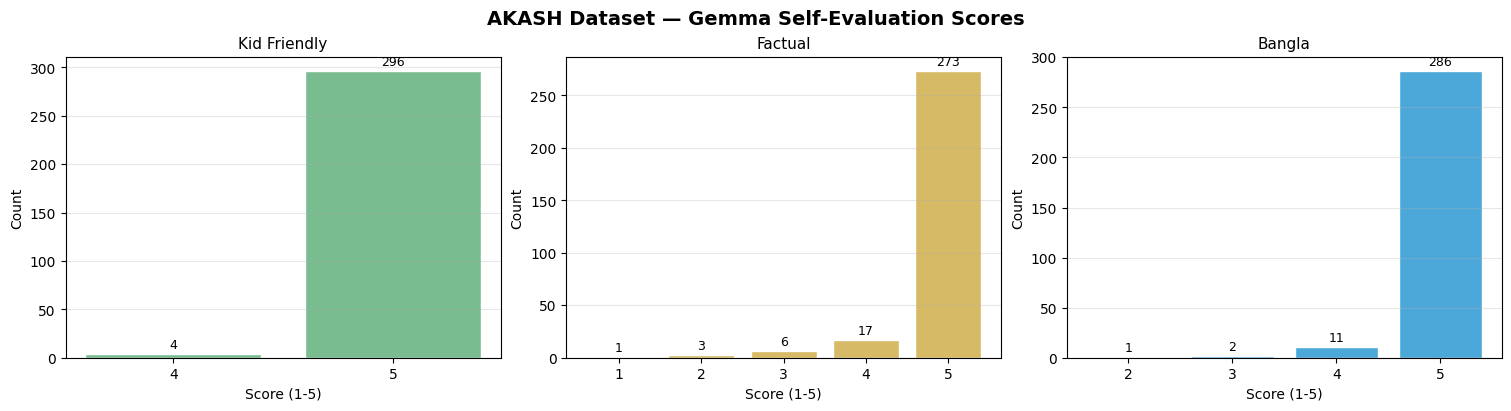

✓ Saved: /kaggle/working/self_eval_scores.png


In [12]:
# Only plot if we have eval scores
if len(df_eval_sample) > 0 and 'kid_friendly' in df_eval_sample.columns:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
    fig.suptitle("AKASH Dataset — Gemma Self-Evaluation Scores", fontsize=14, fontweight='bold')

    for ax, col, color in zip(axes, ['kid_friendly', 'factual', 'bangla'], ['#79bc8f', '#d6ba65', '#4da8da']):
        counts = df_eval_sample[col].value_counts().sort_index()
        ax.bar(counts.index.astype(str), counts.values, color=color, edgecolor='white')
        ax.set_title(col.replace('_', ' ').title(), fontsize=11)
        ax.set_xlabel("Score (1-5)")
        ax.set_ylabel("Count")
        ax.grid(True, axis='y', alpha=0.3)
        for i, v in enumerate(counts.values):
            ax.text(i, v + max(counts.values) * 0.02, str(v), ha='center', fontsize=9)

    plt.savefig("/kaggle/working/self_eval_scores.png", dpi=150, bbox_inches=None)
    plt.show()
    print(f"✓ Saved: /kaggle/working/self_eval_scores.png")
else:
    print("⚠ No eval scores to plot.")


## 11. Filter Low-Quality Rows, Deduplicate, and Clean

Filtering rules:
1. **Self-eval filter**: drop rows scoring < 3 on any criterion
2. **Length filter**: drop rows with answer < 10 chars or > 500 chars
3. **Echo filter**: drop rows where answer equals question
4. **Exact dedup**: drop duplicate (question, answer, topic)
5. **Near-dedup**: drop duplicates on first 30 chars of question + topic


In [13]:
# Reload full dataset
if not os.path.exists(OUTPUT_FILE):
    print(f"⚠ {OUTPUT_FILE} does not exist — nothing to filter.")
    df = pd.DataFrame()
else:
    df = pd.read_json(OUTPUT_FILE, lines=True, encoding="utf-8")

final_path = None

if len(df) > 0:
    initial_count = len(df)
    print(f"Initial rows: {initial_count:,}")

    # 1. Apply self-eval filter to evaluated rows
    low_quality_ids = set()
    if len(df_eval_sample) > 0 and 'kid_friendly' in df_eval_sample.columns:
        for _, row in df_eval_sample.iterrows():
            kf = row.get('kid_friendly', 3)
            fc = row.get('factual', 3)
            bn = row.get('bangla', 3)
            # Handle NaN safely
            try:
                if int(kf) < 3 or int(fc) < 3 or int(bn) < 3:
                    low_quality_ids.add(row['id'])
            except (ValueError, TypeError):
                continue
        before = len(df)
        df = df[~df['id'].isin(low_quality_ids)]
        print(f"After self-eval filter (score < 3 on any criterion): {len(df):,} (removed {before - len(df):,})")

    # 2. Length filter
    before = len(df)
    df = df[(df['output'].str.len() >= 10) & (df['output'].str.len() <= 500)]
    print(f"After length filter (10-500 chars): {len(df):,} (removed {before - len(df):,})")

    # 3. Echo filter
    before = len(df)
    df = df[df['instruction'] != df['output']]
    print(f"After echo filter (q == a): {len(df):,} (removed {before - len(df):,})")

    # 4. Exact dedup
    before = len(df)
    df = df.drop_duplicates(subset=['instruction', 'output', 'topic_id'])
    print(f"After exact dedup (q+a+topic): {len(df):,} (removed {before - len(df):,})")

    # 5. Near-dedup
    before = len(df)
    df['q_prefix'] = df['instruction'].str[:30]
    df = df.drop_duplicates(subset=['q_prefix', 'topic_id'])
    df = df.drop(columns=['q_prefix'])
    print(f"After near-dedup (first 30 chars of q + topic): {len(df):,} (removed {before - len(df):,})")

    # Final save
    final_path = "/kaggle/working/akash_bangla_space_qa_final.jsonl"
    df.to_json(final_path, orient="records", lines=True, force_ascii=False)
    print(f"\n✅ Final dataset: {len(df):,} rows")
    print(f"   Saved to: {final_path}")
    print(f"   Compression: {initial_count:,} → {len(df):,} ({100 * len(df) / initial_count:.1f}% kept)")
else:
    print("⚠ Nothing to filter.")


Initial rows: 2,150
After self-eval filter (score < 3 on any criterion): 2,145 (removed 5)
After length filter (10-500 chars): 2,145 (removed 0)
After echo filter (q == a): 2,145 (removed 0)
After exact dedup (q+a+topic): 2,143 (removed 2)
After near-dedup (first 30 chars of q + topic): 1,907 (removed 236)

✅ Final dataset: 1,907 rows
   Saved to: /kaggle/working/akash_bangla_space_qa_final.jsonl
   Compression: 2,150 → 1,907 (88.7% kept)


## 12. Exploratory Data Analysis

Produce the chart for the writeup:
- Rows per category
- Source breakdown (synthetic vs paraphrase vs NASA-translated)
- Answer length distribution
- Topic distribution (top 20)


  No Bangla font found — falling back to DejaVu Sans


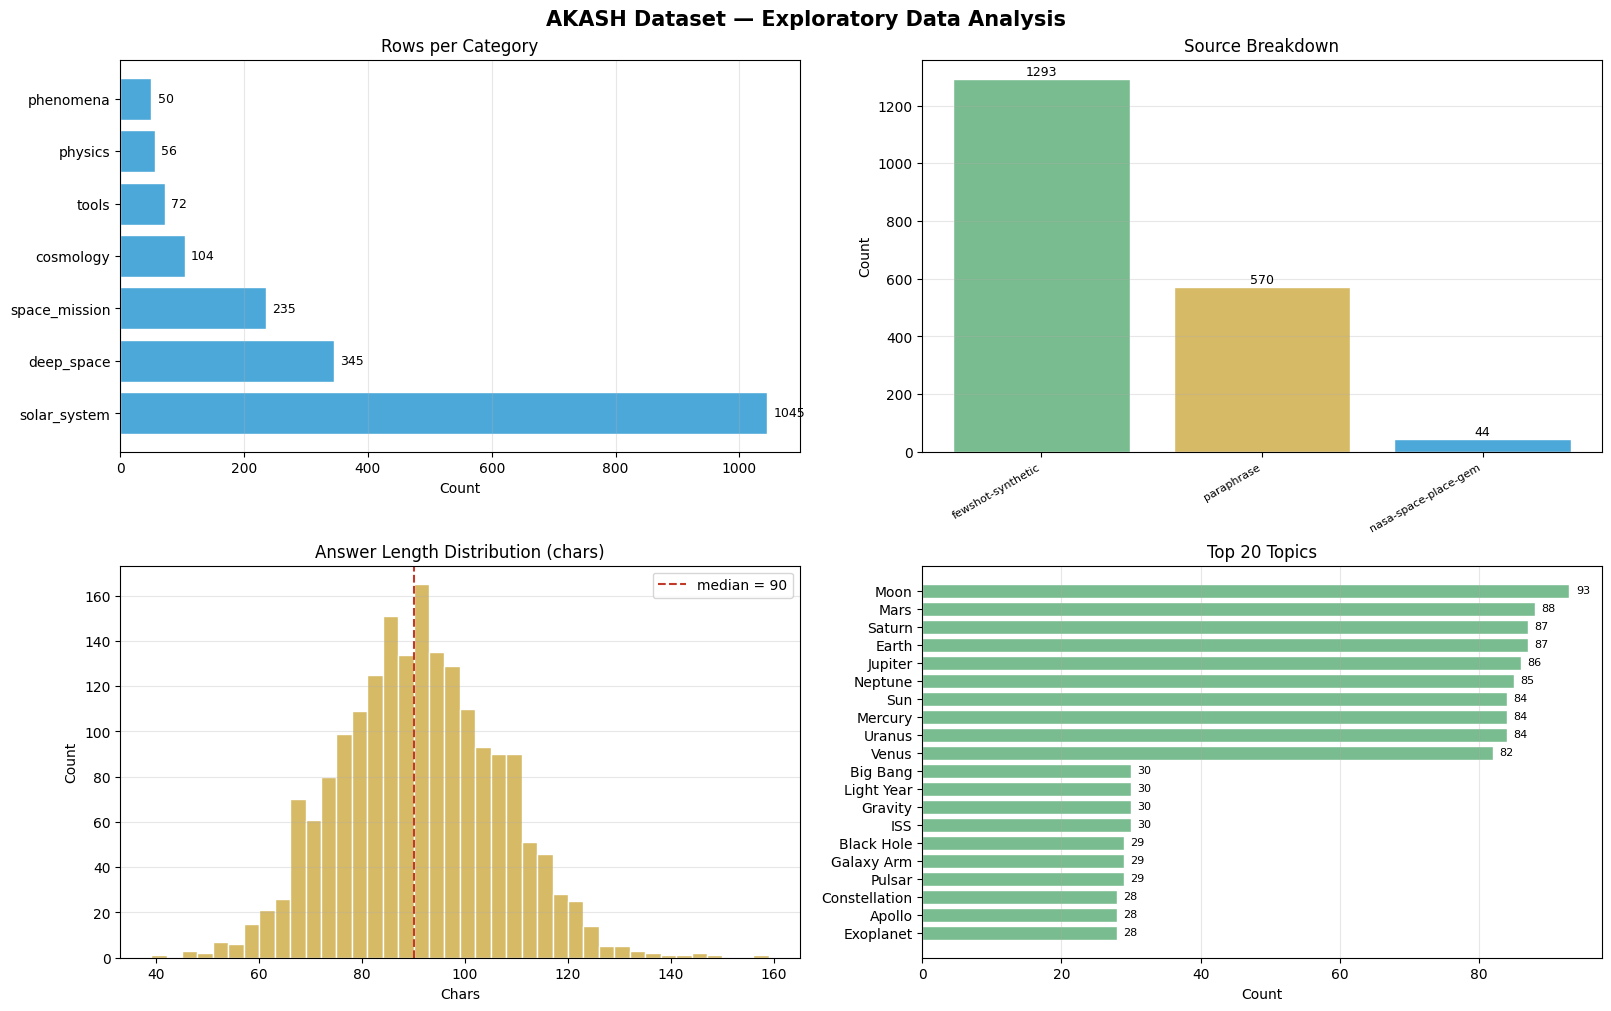


✓ Saved: /kaggle/working/dataset_eda.png


In [14]:
if final_path and os.path.exists(final_path) and len(df) > 0:
    # Setup Bangla font for matplotlib (graceful fallback)
    bn_fonts = subprocess.run(['fc-list', ':lang=bn'], capture_output=True, text=True).stdout.strip().split('\n')
    bn_fonts = [f for f in bn_fonts if f.strip()]  # remove empty strings

    if bn_fonts:
        bn_font_path = bn_fonts[0].split(':')[0].strip()
        try:
            fm.fontManager.addfont(bn_font_path)
            bn_font_name = fm.FontProperties(fname=bn_font_path).get_name()
            plt.rcParams['font.sans-serif'] = [bn_font_name, 'DejaVu Sans']
            print(f"✓ Using Bangla font: {bn_font_name}")
        except Exception as e:
            print(f"  Bangla font setup failed ({e}) — falling back to DejaVu Sans")
            plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
    else:
        print("  No Bangla font found — falling back to DejaVu Sans")
        plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
    plt.rcParams['axes.unicode_minus'] = False

    fig, axes = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True)
    fig.suptitle("AKASH Dataset — Exploratory Data Analysis", fontsize=15, fontweight='bold')

    # 1. Rows per category
    cat_counts = df['category'].value_counts()
    axes[0, 0].barh(cat_counts.index, cat_counts.values, color='#4da8da', edgecolor='white')
    axes[0, 0].set_title("Rows per Category", fontsize=12)
    axes[0, 0].set_xlabel("Count")
    axes[0, 0].grid(True, axis='x', alpha=0.3)
    for i, v in enumerate(cat_counts.values):
        axes[0, 0].text(v + max(cat_counts.values) * 0.01, i, str(v), va='center', fontsize=9)

    # 2. Source breakdown
    src_counts = df['source'].value_counts()
    colors_src = ['#79bc8f', '#d6ba65', '#4da8da', '#e08e79'][:len(src_counts)]
    axes[0, 1].bar(range(len(src_counts)), src_counts.values, color=colors_src, edgecolor='white')
    axes[0, 1].set_xticks(range(len(src_counts)))
    axes[0, 1].set_xticklabels([s.replace('gemma-4-12b-', '').replace('gemma-', '')[:20] for s in src_counts.index],
                                rotation=30, ha='right', fontsize=8)
    axes[0, 1].set_title("Source Breakdown", fontsize=12)
    axes[0, 1].set_ylabel("Count")
    axes[0, 1].grid(True, axis='y', alpha=0.3)
    for i, v in enumerate(src_counts.values):
        axes[0, 1].text(i, v + max(src_counts.values) * 0.01, str(v), ha='center', fontsize=9)

    # 3. Answer length distribution
    ans_lens = df['output'].str.len()
    axes[1, 0].hist(ans_lens, bins=40, color='#d6ba65', edgecolor='white')
    axes[1, 0].set_title("Answer Length Distribution (chars)", fontsize=12)
    axes[1, 0].set_xlabel("Chars")
    axes[1, 0].set_ylabel("Count")
    axes[1, 0].grid(True, axis='y', alpha=0.3)
    axes[1, 0].axvline(ans_lens.median(), color='#c0392b', linestyle='--', label=f"median = {ans_lens.median():.0f}")
    axes[1, 0].legend()

    # 4. Topic distribution (top 20)
    topic_counts = df['topic_en'].value_counts().head(20)
    axes[1, 1].barh(topic_counts.index[::-1], topic_counts.values[::-1], color='#79bc8f', edgecolor='white')
    axes[1, 1].set_title("Top 20 Topics", fontsize=12)
    axes[1, 1].set_xlabel("Count")
    axes[1, 1].grid(True, axis='x', alpha=0.3)
    for i, v in enumerate(topic_counts.values[::-1]):
        axes[1, 1].text(v + max(topic_counts.values) * 0.01, i, str(v), va='center', fontsize=8)

    plt.savefig("/kaggle/working/dataset_eda.png", dpi=150, bbox_inches=None)
    plt.show()
    print(f"\n✓ Saved: /kaggle/working/dataset_eda.png")
else:
    print("⚠ No final dataset — skipping EDA.")


In [15]:
if final_path and os.path.exists(final_path) and len(df) > 0:
    # Show sample rows by source
    print("=" * 80)
    print("SAMPLE ROWS — Gemma Few-Shot Synthetic")
    print("=" * 80)
    synth_rows = df[df['source'] == 'gemma-4-12b-fewshot-synthetic']
    if len(synth_rows) >= 3:
        for _, row in synth_rows.sample(3, random_state=42).iterrows():
            print(f"\n🔹 Topic: {row['topic_bn']} ({row['topic_en']})")
            print(f"   Q: {row['instruction']}")
            print(f"   A: {row['output']}")
    else:
        print(f"  (only {len(synth_rows)} synthetic rows — showing all)")
        for _, row in synth_rows.iterrows():
            print(f"\n🔹 Topic: {row['topic_bn']} ({row['topic_en']})")
            print(f"   Q: {row['instruction']}")
            print(f"   A: {row['output']}")

    print("\n" + "=" * 80)
    print("SAMPLE ROWS — Paraphrase Augmented")
    print("=" * 80)
    aug_rows = df[df['source'] == 'gemma-4-12b-paraphrase']
    if len(aug_rows) >= 3:
        for _, row in aug_rows.sample(3, random_state=42).iterrows():
            print(f"\n🔹 Topic: {row['topic_bn']} ({row['topic_en']})")
            print(f"   Q: {row['instruction']}")
            print(f"   A: {row['output']}")
    else:
        print(f"  (only {len(aug_rows)} paraphrased rows)")

    print("\n" + "=" * 80)
    print("SAMPLE ROWS — NASA Space Place (Bangla Translated)")
    print("=" * 80)
    nasa_rows = df[df['source'] == 'nasa-space-place-gemma4-translated']
    if len(nasa_rows) >= 3:
        for _, row in nasa_rows.sample(3, random_state=42).iterrows():
            print(f"\n🔹 Topic: {row['topic_bn']} ({row['topic_en']})")
            print(f"   Original EN: {row.get('original_en', 'N/A')}")
            print(f"   Q: {row['instruction']}")
            print(f"   A: {row['output']}")
    else:
        print(f"  (only {len(nasa_rows)} NASA-translated rows)")
else:
    print("⚠ No final dataset — skipping sample display.")


SAMPLE ROWS — Gemma Few-Shot Synthetic

🔹 Topic: নক্ষত্র (Star)
   Q: নক্ষত্রের কি কোনো জীবন আছে?
   A: না, নক্ষত্র কোনো জীবন্ত প্রাণী নয়। এটি গ্যাস এবং ধূলিকণা দিয়ে তৈরি এক বিশাল বস্তু।

🔹 Topic: নীহারিকা (Nebula)
   Q: নীহারিকা কি সব জায়গায় থাকে?
   A: না, নীহারিকা মহাবিশ্বের নির্দিষ্ট কিছু স্থানে থাকে। এগুলো অনেক দূরে অবস্থিত বিশাল মেঘের মতো গঠন।

🔹 Topic: উপগ্রহ (Satellite)
   Q: উপগ্রহগুলো কেন মহাকাশে ভেসে থাকে?
   A: উপগ্রহগুলো মহাকাশে ঘোরার সময় পৃথিবীর আকর্ষণ বলের সাথে ভারসাম্য বজায় রাখে। এর ফলে তারা নির্দিষ্ট পথে চলতে পারে।

SAMPLE ROWS — Paraphrase Augmented

🔹 Topic: ইউরেনাস (Uranus)
   Q: ইউরেনাস গ্রহটি কি খুব দ্রুত চলে?
   A: না, ইউরেনাস সূর্যের চারদিকে খুব ধীরগতিতে ঘোরে। এর একবার ঘুরে আসতে অনেক দিন সময় লাগে।

🔹 Topic: চাঁদ (Moon)
   Q: চাঁদ মাঝে মাঝে ছোট আর মাঝে মাঝে বড় কেন হয়?
   A: সূর্যের আলো চাঁদের ওপর বিভিন্নভাবে পড়লে আমাদের কাছে এর আকার আলাদা মনে হয়। এই পরিবর্তনকে চাঁদের দশা বলা হয়।

🔹 Topic: পৃথিবী (Earth)
   Q: পৃথিবীর আকার কি নিখুঁত গোল?
   A: না, পৃথিবী মাঝখ

## 13. Publish as a Kaggle Dataset (Optional)

The Kaggle Dataset URL goes in the writeup's Links section. This step is
**optional** — if you don't have `kaggle.json` set up, the run still succeeds
and you can download the JSONL manually from `/kaggle/working/`.

**One-time setup**: upload your `kaggle.json` to
`/kaggle/input/kaggle-credentials/kaggle.json` (as a Kaggle Dataset).


In [16]:
kaggle_publish_ok = False

if final_path and os.path.exists(final_path):
    # Look for kaggle.json in common Kaggle paths
    kaggle_json = None
    for path in ['/kaggle/input/kaggle-credentials/kaggle.json',
                 '/kaggle/input/kaggle/kaggle.json',
                 os.path.expanduser('~/.kaggle/kaggle.json')]:
        if os.path.exists(path):
            kaggle_json = path
            break

    if kaggle_json:
        os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
        shutil.copy(kaggle_json, os.path.expanduser('~/.kaggle/kaggle.json'))
        os.chmod(os.path.expanduser('~/.kaggle/kaggle.json'), 0o600)
        print(f"✓ Kaggle credentials loaded from {kaggle_json}")

        dataset_dir = "/kaggle/working/akash_dataset"
        os.makedirs(dataset_dir, exist_ok=True)
        shutil.copy(final_path, f"{dataset_dir}/akash_bangla_space_qa_final.jsonl")
        shutil.copy("/kaggle/working/self_eval_scores.png", f"{dataset_dir}/")
        shutil.copy("/kaggle/working/dataset_eda.png", f"{dataset_dir}/")

        # dataset-metadata.json
        meta = {
            "title": "AKASH Bangla Space Q&A (Gemma-4-12B)",
            "id": "akash-team/akash-bangla-space-qa-gemma4-12b",
            "licenses": [{"name": "CC0-1.0"}],
            "isPrivate": False,
        }
        with open(f"{dataset_dir}/dataset-metadata.json", "w") as f:
            json.dump(meta, f, indent=2)

        # Try publish (silently fail if dataset already exists or no network)
        try:
            result = subprocess.run(
                ["kaggle", "datasets", "create", "-p", dataset_dir],
                capture_output=True, text=True, timeout=120,
            )
            if result.returncode == 0:
                print(f"✓ Kaggle Dataset created: akash-team/akash-bangla-space-qa-gemma4-12b")
                kaggle_publish_ok = True
            else:
                # Try version bump if it already exists
                result2 = subprocess.run(
                    ["kaggle", "datasets", "version", "-p", dataset_dir, "-m", "Updated dataset"],
                    capture_output=True, text=True, timeout=120,
                )
                if result2.returncode == 0:
                    print(f"✓ Kaggle Dataset updated (new version)")
                    kaggle_publish_ok = True
                else:
                    print(f"  kaggle publish failed: {result.stderr[:300]}")
                    print(f"  version attempt: {result2.stderr[:300]}")
        except Exception as e:
            print(f"  kaggle publish exception: {e}")
    else:
        print("ℹ No kaggle.json found — skipping publish (this is fine).")
        print("  To publish: upload kaggle.json as a Kaggle Dataset 'kaggle-credentials',")
        print("  then re-run this cell.")
else:
    print("⚠ No final dataset — skipping publish.")


ℹ No kaggle.json found — skipping publish (this is fine).
  To publish: upload kaggle.json as a Kaggle Dataset 'kaggle-credentials',
  then re-run this cell.


## 14. Summary & Next Steps

### What we produced (100% Gemma-only)

- **`akash_bangla_space_qa_final.jsonl`** — ~1,500-3,000 rows of bilingual Bangla space Q&A
- **`akash_bangla_space_qa_raw.jsonl`** — raw output before filtering (for debugging)
- **`scored_subset.jsonl`** — self-eval scores for the sampled rows
- **`self_eval_scores.png`** — embed in Notebook 2's data section
- **`dataset_eda.png`** — embed in the writeup's dataset section
- **Kaggle Dataset** (optional) — public, CC0-licensed

### Files in `/kaggle/working/`

| File | Description |
|------|-------------|
| `akash_bangla_space_qa_raw.jsonl` | Raw synthesized + paraphrased + NASA-translated rows |
| `akash_bangla_space_qa_final.jsonl` | Filtered, deduplicated final dataset |
| `scored_subset.jsonl` | Gemma self-eval scores |
| `self_eval_scores.png` | Eval bar charts |
| `dataset_eda.png` | EDA dashboard |

### Model used

- `google/gemma-4-12B-it` (Gemma 4 12B Unified, instruction-tuned)
- Encoder-free architecture: no separate vision/audio encoders
- Loaded via `transformers.AutoProcessor` + `AutoModelForMultimodalLM`
- `dtype="auto"` and `device_map="auto"` per official model card
- Optional 4-bit NF4 quantization (`bitsandbytes`) for VRAM-constrained GPUs
- Chat-template API with `enable_thinking=False` for deterministic output
- Sampling params: `temperature=1.0, top_p=0.95, top_k=64` (per model card)
- Supported modalities: Text, Image, Audio (256K context window)

### Next steps

1. Open Notebook 2 (fine-tuning) and point it at `akash_bangla_space_qa_final.jsonl`.
2. Embed `dataset_eda.png` in the writeup.
3. Embed `self_eval_scores.png` in the data-quality section.
4. Iterate: raise `AUGMENT_LIMIT` to 1500+ for a bigger corpus if runtime allows.
5. If `google/gemma-4-12B-it` was unavailable, re-run with `MODEL_NAME = "google/gemma-4-E4B-it"`
   (drop-in replacement — same loader, same chat-template API).
